# Projeto I EDA — Parte A: Pesquisa de opinião CESOP/IPEC 04829

**Tema:** percepção dos brasileiros sobre racismo, desigualdades, políticas públicas e ações afirmativas.

Este notebook foi estruturado para execução em Google Colab a partir da pasta do projeto. Ele usa:

- microdados da pesquisa CESOP/IPEC 04829, convertidos de `.SAV` para `.csv`;
- questionário e tabela de frequências da pesquisa, preservados em `data/raw/`;
- uma base pública externa do IBGE/Censo 2022 sobre distribuição da população por raça/cor por Unidade da Federação.

## Perguntas orientadoras

1. Qual dimensão é mais apontada como geradora de desigualdades no Brasil?
2. A percepção de que o Brasil é racista aparece junto a relatos pessoais ou indiretos de racismo?
3. O relato de ter sofrido racismo varia por raça/cor autodeclarada?
4. O apoio a cotas raciais varia por raça/cor e por posicionamento político?
5. A composição racial da amostra se aproxima da distribuição nacional do Censo 2022?


## Introdução

Nesta parte analisamos a pesquisa CESOP/IPEC 04829, sobre a percepção dos brasileiros a respeito do racismo. O levantamento foi feito entre 14 e 18 de abril de 2023, com 2.000 entrevistas e universo de eleitores de 16 anos ou mais. O questionário cobre raça/cor/etnia, experiências de racismo, racismo ambiental, escola, segurança pública, representatividade, cotas e ações afirmativas, acessibilidade, religião, renda e perfil sociodemográfico.

Partimos das cinco perguntas listadas acima e, para cada uma, montamos a tabela ou o cruzamento correspondente. Para atender à exigência de correlação com uma base pública, comparamos a composição racial da amostra com a distribuição da população por raça/cor no Censo Demográfico 2022 do IBGE. A comparação serve para situar a amostra diante de uma referência nacional, e não para corrigir seus pesos.

## Métodos

A análise é exploratória e descritiva. Trabalhamos com tabelas de frequência, gráficos de barras e cruzamentos entre variáveis categóricas. Para medir a associação entre pares de variáveis nominais, aplicamos o teste qui-quadrado de independência e o V de Cramér, que resume a força dessa associação.

Os microdados vieram em formato SPSS (.SAV) e foram convertidos para CSV por um leitor próprio, em `src/spss_sav_minimal_reader.py`, preservando os rótulos de variáveis e de valores. Nas frequências gerais mantivemos as respostas "não sabe" e "não respondeu"; já nos cruzamentos por grupo e nos testes trabalhamos apenas com as respostas substantivas, para não diluir os percentuais. A base não traz variável de peso amostral, então os resultados são calculados sem ponderação. As conclusões são associativas, não causais.

In [1]:
import sys, subprocess
from pathlib import Path
import os, json, warnings
warnings.filterwarnings("ignore")

# URL deste repositório no GitHub (já configurado).
REPO_URL = "https://github.com/Furlovers/projeto-dc-eda.git"

# No Google Colab, baixamos o projeto (dados + notebooks) direto do GitHub.
# Em execução local, esta etapa é ignorada e usamos a própria pasta do projeto.
IN_COLAB = "google.colab" in sys.modules
COLAB_DIR = Path("/content/projeto_i_eda")
if IN_COLAB and not (COLAB_DIR / "data").exists():
    print("Colab detectado: baixando o projeto do GitHub...")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(COLAB_DIR)], check=True)

# Procuramos a raiz do projeto (a pasta que contém data/), seja local ou no Colab.
candidate_roots = [Path.cwd(), Path.cwd().parent, COLAB_DIR, Path("/content")]
ROOT = next((c for c in candidate_roots if (c / "data").exists()), None)
if ROOT is None:
    raise FileNotFoundError(
        "Não encontrei a pasta data/. No Colab, confira o REPO_URL acima e rode esta célula de novo."
    )

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
DATA_EXTERNAL = ROOT / "data" / "external"
print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: C:\Users\breno\Projects\faculdade\ciencia-de-dados\projeto_i_eda


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

micro_path = DATA_PROCESSED / "cesop_04829_microdados.csv"
codebook_path = DATA_PROCESSED / "cesop_04829_codebook.csv"
labels_path = DATA_PROCESSED / "cesop_04829_value_labels.json"
ibge_path = DATA_EXTERNAL / "ibge_censo2022_raca_uf.csv"

dados = pd.read_csv(micro_path)
codebook = pd.read_csv(codebook_path)
with open(labels_path, encoding="utf-8") as f:
    labels = json.load(f)

print(dados.shape)
display(codebook.head(10))


(2000, 144)


,name,long_name,label,type,spss_index,label_set_id,value_labels_json,non_missing_count,missing_count
0,SEXO,SEXO,NaN,numeric,1,0.0,"{""1"": ""MAS"", ""2"": ""FEM""}",2000,0
1,IDADE,IDADE,NaN,numeric,2,NaN,{},2000,0
2,FX_ID,FX_ID,FAIXAS IDADES,numeric,3,1.0,"{""1"": ""16 A 24"", ""2"": ""25 A 34"", ""3"": ""35 A 44...",2000,0
3,RACA,RACA,RACA/ COR,numeric,4,2.0,"{""1"": ""Branca"", ""2"": ""Preta"", ""3"": ""Parda"", ""4...",2000,0
4,ESCOLARI,ESCOLARIDADE,NaN,numeric,5,3.0,"{""1"": ""Analfabeto"", ""2"": ""Sabe ler/ escrever, ...",2000,0
5,P1,P1,"P.01) Dentre as questões listadas a seguir, na...",numeric,6,4.0,"{""1"": ""Raça/Cor/Etnia"", ""2"": ""Classe social"", ...",2000,0
6,P2,P2,P.02) Gostaria de saber como o(a) sr(a) se sen...,numeric,7,5.0,"{""1"": ""Muito confortável"", ""2"": ""Confortável"",...",2000,0
7,P3,P3,"P.03) Para o(a) sr(a), definir a sua raça/cor/...",numeric,8,6.0,"{""1"": ""Muito fácil"", ""2"": ""Fácil"", ""3"": ""Difíc...",2000,0
8,P4,P4,"P.04) Na sua opinião, declarar a sua raça/cor/...",numeric,9,7.0,"{""1"": ""Muito importante"", ""2"": ""Pouco importan...",2000,0
9,P5A,P5A,P.05A) Diga se concorda ou discorda de cada af...,numeric,10,8.0,"{""1"": ""Concordo totalmente"", ""2"": ""Concordo em...",2000,0


In [3]:

def label_map(var):
    """Retorna dicionário {código: rótulo} para uma variável."""
    return {int(k): v for k, v in labels.get(var, {}).items()}

def labeled_series(var):
    return dados[var].map(label_map(var)).fillna(dados[var].astype(str))

def freq_percent(var, include_missing=True):
    s = dados[var]
    counts = s.value_counts(dropna=not include_missing).sort_index()
    out = counts.rename("n").reset_index().rename(columns={"index": "codigo", var: "codigo"})
    out["percentual"] = out["n"] / len(s) * 100
    mapper = label_map(var)
    out["resposta"] = out["codigo"].map(mapper).fillna(out["codigo"].astype(str))
    return out[["codigo", "resposta", "n", "percentual"]]

def share_positive_by_group(group_var, response_var, positive_codes, valid_response_codes=None):
    d = dados.copy()
    if valid_response_codes is not None:
        d = d[d[response_var].isin(valid_response_codes)]
    rows = []
    mapper = label_map(group_var)
    for group_code, sub in d.groupby(group_var, dropna=True):
        rows.append({
            "grupo_codigo": group_code,
            "grupo": mapper.get(int(group_code), str(group_code)) if pd.notna(group_code) else "NA",
            "n": len(sub),
            "percentual": sub[response_var].isin(positive_codes).mean() * 100
        })
    return pd.DataFrame(rows).sort_values("grupo_codigo")

def cramers_v(contingency):
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    v = np.sqrt((chi2 / n) / min(k - 1, r - 1))
    return {"chi2": chi2, "p_valor": p, "gl": dof, "v_cramer": v}

def pct_fmt(x):
    return f"{x:.1f}%"

print("Variáveis-chave disponíveis:")
display(codebook[codebook["name"].isin(["P1", "P5A", "P5B", "P5D", "P19A", "P19B", "P21B", "P_POLITI", "RACA"])][["name","long_name","label","value_labels_json"]])


Variáveis-chave disponíveis:


,name,long_name,label,value_labels_json
3,RACA,RACA,RACA/ COR,"{""1"": ""Branca"", ""2"": ""Preta"", ""3"": ""Parda"", ""4..."
5,P1,P1,"P.01) Dentre as questões listadas a seguir, na...","{""1"": ""Raça/Cor/Etnia"", ""2"": ""Classe social"", ..."
9,P5A,P5A,P.05A) Diga se concorda ou discorda de cada af...,"{""1"": ""Concordo totalmente"", ""2"": ""Concordo em..."
10,P5B,P5B,P.05B) Diga se concorda ou discorda de cada af...,"{""1"": ""Concordo totalmente"", ""2"": ""Concordo em..."
12,P5D,P5D,P.05D) Diga se concorda ou discorda de cada af...,"{""1"": ""Concordo totalmente"", ""2"": ""Concordo em..."
93,P19A,P19A,P.19A) Diga se concorda ou discorda de cada af...,"{""1"": ""Concordo totalmente"", ""2"": ""Concordo em..."
94,P19B,P19B,P.19B) Diga se concorda ou discorda de cada af...,"{""1"": ""Concordo totalmente"", ""2"": ""Concordo em..."
108,P21B,P21B,P.21B) Pensando em vagas em faculdades/univers...,"{""1"": ""A favor"", ""2"": ""Contra"", ""98"": ""Não sab..."
133,P_POLITI,P_POLITICA,"P.POLÍTICA) Na política, as pessoas normalment...","{""1"": ""Mais à esquerda"", ""2"": ""No centro"", ""3""..."


## 1. Perfil da amostra e comparação com o Censo 2022

,codigo,resposta,n,percentual
0,1,Branca,893,44.65
1,2,Preta,210,10.50
2,3,Parda,876,43.80
3,4,Amarela,11,0.55
4,5,Indígena,10,0.50


,raca,Pesquisa CESOP/IPEC,IBGE Censo 2022
0,Amarela,0.55,0.418617
1,Branca,44.65,43.456664
2,Indígena,0.50,0.834563
3,Parda,43.80,45.343187
4,Preta,10.50,10.171549


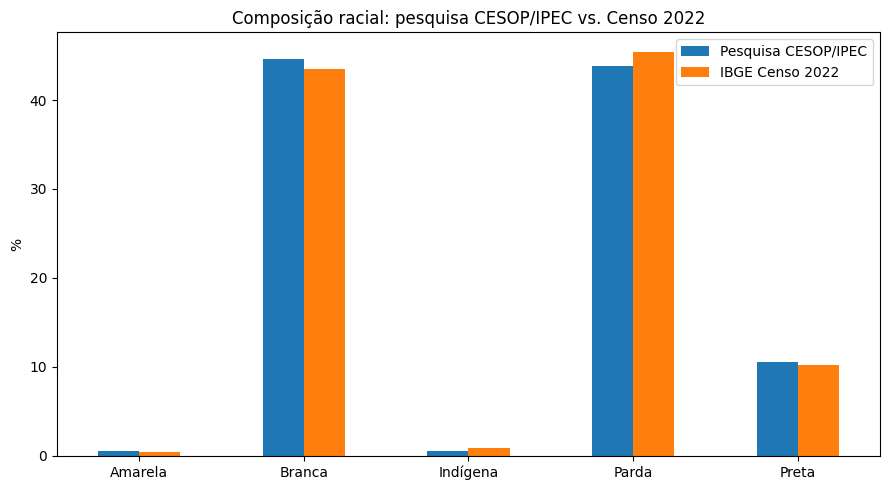

In [4]:

# Distribuição de raça/cor na pesquisa
raca = freq_percent("RACA")
display(raca)

# Base externa: IBGE Censo 2022 por raça/cor
ibge = pd.read_csv(ibge_path)
brasil = ibge[ibge["nome"] == "Brasil"].iloc[0]

ibge_long = pd.DataFrame({
    "raca": ["Branca", "Preta", "Parda", "Amarela", "Indígena"],
    "IBGE Censo 2022": [
        brasil["branca_pct_total"],
        brasil["preta_pct_total"],
        brasil["parda_pct_total"],
        brasil["amarela_pct_total"],
        brasil["indigena_pct_total"],
    ],
})

survey_long = raca[raca["codigo"].isin([1, 2, 3, 4, 5])][["resposta", "percentual"]].rename(
    columns={"resposta": "raca", "percentual": "Pesquisa CESOP/IPEC"}
)

comparacao = survey_long.merge(ibge_long, on="raca", how="outer")
display(comparacao)

ax = comparacao.set_index("raca")[["Pesquisa CESOP/IPEC", "IBGE Censo 2022"]].plot(kind="bar", figsize=(9, 5))
ax.set_title("Composição racial: pesquisa CESOP/IPEC vs. Censo 2022")
ax.set_ylabel("%")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


A amostra reproduz bem as grandes categorias do Censo 2022. Brancos somam 44,6% (43,5% no Censo) e pardos 43,8% (45,3% no Censo); pretos ficam em 10,5% (10,2%). Amarelos e indígenas somam cerca de 1% da amostra, de modo que qualquer cruzamento que dependa dessas categorias precisa ser lido com cautela. Como os percentuais da pesquisa e do Censo estão próximos, usamos a comparação apenas como contexto demográfico, sem reponderar a amostra.

## 2. Desigualdades, racismo e experiências relatadas

,codigo,resposta,n,percentual
0,1,Raça/Cor/Etnia,883,44.15
1,2,Classe social,581,29.05
3,4,"Local de moradia (cidade, região da cidade, ba...",142,7.10
2,3,Gênero ou sexo,117,5.85
5,6,"Orientação sexual (heterossexual, homossexual)",91,4.55
8,99,Não sabe/ Não respondeu,76,3.80
4,5,"Deficiência (auditiva, visual, intelectual e m...",39,1.95
7,97,Nenhuma destas/Outras (sem especificar),38,1.90
6,7,Local de origem/onde nasceu (país ou região do...,33,1.65


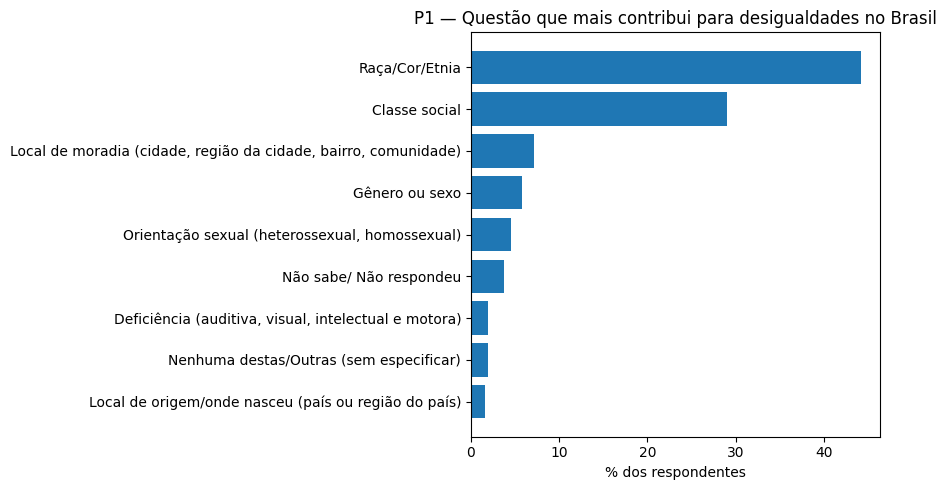

In [5]:

# P1: principal fator que contribui para desigualdades no Brasil
p1 = freq_percent("P1").sort_values("percentual", ascending=True)
display(p1.sort_values("percentual", ascending=False))

plt.figure(figsize=(9, 5))
plt.barh(p1["resposta"], p1["percentual"])
plt.title("P1 — Questão que mais contribui para desigualdades no Brasil")
plt.xlabel("% dos respondentes")
plt.tight_layout()
plt.show()


,variavel,indicador,concorda_total_ou_parcial_pct
6,P19B,Pessoas negras são mais criminalizadas e punidas,87.95
5,P19A,Brancos e negros são tratados de forma diferen...,84.05
0,P5A,O Brasil é um país racista,80.90
7,P19C,Abordagem policial baseada em cor/cabelo/vesti...,79.05
8,P19E,Representatividade negra em poder reduz desigu...,75.45
2,P5D,Já presenciei alguém sofrer racismo,62.65
3,P5G,Convivo com pessoas que sofrem racismo,46.45
4,P5H,Convivo com pessoas com atitudes racistas,35.10
1,P5B,Eu sofro ou já sofri racismo,23.30


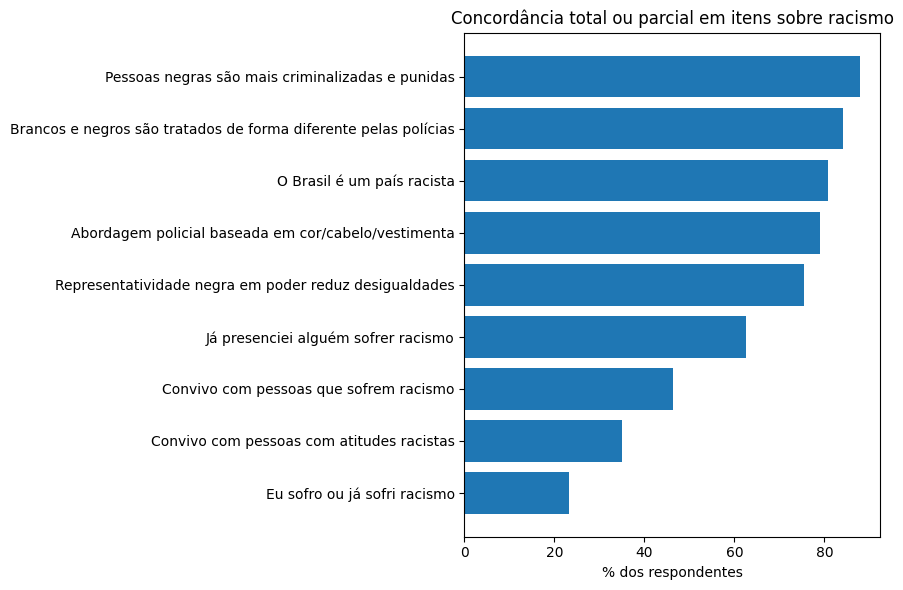

In [6]:

# Síntese de concordância em itens selecionados
itens = {
    "P5A": "O Brasil é um país racista",
    "P5B": "Eu sofro ou já sofri racismo",
    "P5D": "Já presenciei alguém sofrer racismo",
    "P5G": "Convivo com pessoas que sofrem racismo",
    "P5H": "Convivo com pessoas com atitudes racistas",
    "P19A": "Brancos e negros são tratados de forma diferente pelas polícias",
    "P19B": "Pessoas negras são mais criminalizadas e punidas",
    "P19C": "Abordagem policial baseada em cor/cabelo/vestimenta",
    "P19E": "Representatividade negra em poder reduz desigualdades",
}
agree = []
for var, desc in itens.items():
    agree.append({
        "variavel": var,
        "indicador": desc,
        "concorda_total_ou_parcial_pct": dados[var].isin([1, 2]).mean() * 100
    })
agree = pd.DataFrame(agree).sort_values("concorda_total_ou_parcial_pct")

display(agree.sort_values("concorda_total_ou_parcial_pct", ascending=False))

plt.figure(figsize=(9, 6))
plt.barh(agree["indicador"], agree["concorda_total_ou_parcial_pct"])
plt.title("Concordância total ou parcial em itens sobre racismo")
plt.xlabel("% dos respondentes")
plt.tight_layout()
plt.show()


Há um reconhecimento amplo do racismo como problema do país: 80,9% concordam, total ou parcialmente, que o Brasil é racista. Sobre a atuação policial, a concordância também é alta — 84,0% acham que brancos e negros são tratados de forma diferente pelas polícias, 87,9% que pessoas negras são mais criminalizadas e 79,0% que a abordagem policial se baseia em cor, cabelo e vestimenta. Já o relato de ter sofrido racismo pessoalmente é bem menor: 23,3% no conjunto da amostra. Esse contraste entre um diagnóstico coletivo amplo e uma experiência pessoal mais restrita é justamente o que investigamos no cruzamento por raça/cor a seguir.

## 3. Experiência de racismo por raça/cor

,grupo_codigo,grupo,n,percentual
0,1,Branca,873,16.265750
1,2,Preta,206,50.000000
2,3,Parda,856,24.766355
3,4,Amarela,11,27.272727
4,5,Indígena,10,60.000000


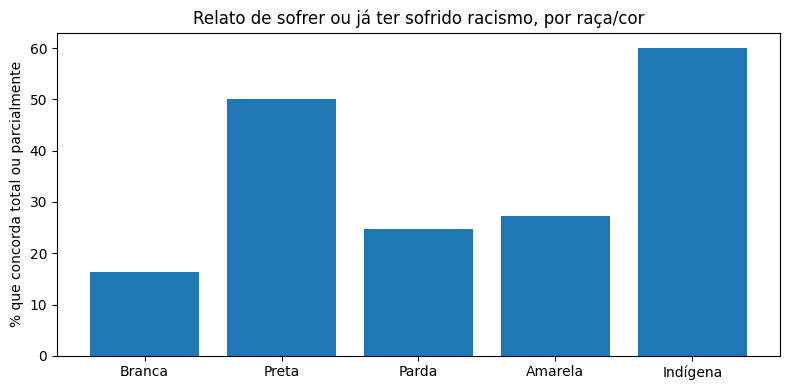

sofreu_racismo,0,1
RACA,,
1,731,142
2,103,103
3,644,212
4,8,3
5,4,6


,chi2,p_valor,gl,v_cramer
0,112.957354,1.702665e-23,4,0.240311


In [7]:

p5b_raca = share_positive_by_group("RACA", "P5B", [1, 2], valid_response_codes=[1, 2, 3, 4, 5])
display(p5b_raca)

plt.figure(figsize=(8, 4))
plt.bar(p5b_raca["grupo"], p5b_raca["percentual"])
plt.title("Relato de sofrer ou já ter sofrido racismo, por raça/cor")
plt.ylabel("% que concorda total ou parcialmente")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Teste qui-quadrado: raça/cor x concorda que sofreu racismo
teste = dados[dados["RACA"].isin([1,2,3,4,5]) & dados["P5B"].isin([1,2,3,4,5])].copy()
teste["sofreu_racismo"] = teste["P5B"].isin([1,2]).astype(int)
ct = pd.crosstab(teste["RACA"], teste["sofreu_racismo"])
display(ct)
display(pd.DataFrame([cramers_v(ct)]))


Entre quem respondeu de forma substantiva, o relato de já ter sofrido racismo varia muito por raça/cor: 16,3% entre brancos, 24,8% entre pardos e 50,0% entre pretos. Indígenas e amarelos aparecem com percentuais altos, mas têm pouquíssimos casos na amostra (cerca de dez cada), então não sustentam conclusão. O qui-quadrado confirma que a distribuição das respostas difere por raça/cor (p < 0,001) e o V de Cramér de 0,240 indica associação de intensidade moderada. É a relação mais nítida desta parte.

## 4. Apoio a cotas raciais e posicionamento político

,grupo_codigo,grupo,n,percentual
0,1,Branca,868,74.078341
1,2,Preta,202,76.732673
2,3,Parda,859,78.114086
3,4,Amarela,11,81.818182
4,5,Indígena,10,80.000000


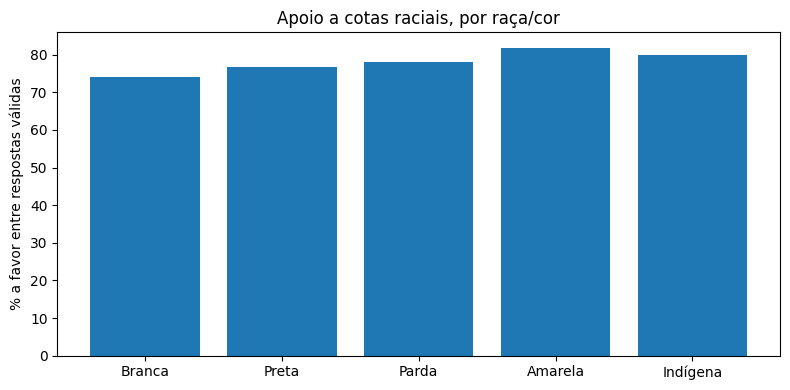

,grupo_codigo,grupo,n,percentual
0,1,Mais à esquerda,419,89.021480
1,2,No centro,369,80.216802
2,3,Mais à direita,557,66.068223
3,4,Não tem posicionamento político (Esp.),547,73.857404
4,99,Não respondeu,58,77.586207


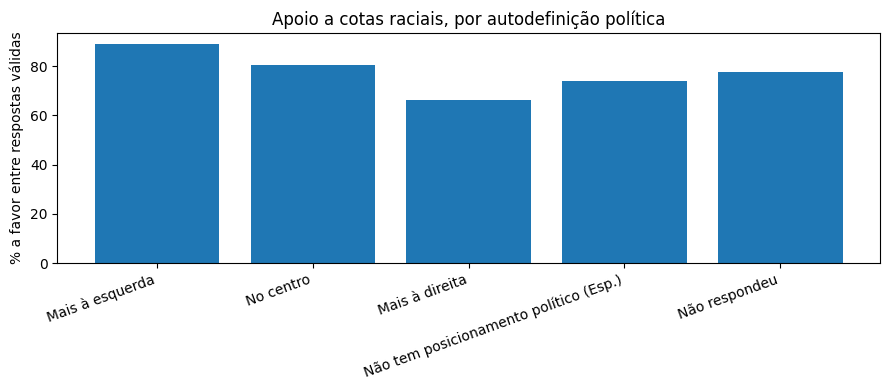

favor_cotas_raciais,0,1
RACA,,
1,225,643
2,47,155
3,188,671
4,2,9
5,2,8


,chi2,p_valor,gl,v_cramer
0,4.193069,0.380507,4,0.046371


In [8]:

p21b_raca = share_positive_by_group("RACA", "P21B", [1], valid_response_codes=[1, 2])
display(p21b_raca)

plt.figure(figsize=(8, 4))
plt.bar(p21b_raca["grupo"], p21b_raca["percentual"])
plt.title("Apoio a cotas raciais, por raça/cor")
plt.ylabel("% a favor entre respostas válidas")
plt.xlabel("")
plt.tight_layout()
plt.show()

p21b_pol = share_positive_by_group("P_POLITI", "P21B", [1], valid_response_codes=[1, 2])
display(p21b_pol)

plt.figure(figsize=(9, 4))
plt.bar(p21b_pol["grupo"], p21b_pol["percentual"])
plt.title("Apoio a cotas raciais, por autodefinição política")
plt.ylabel("% a favor entre respostas válidas")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Teste qui-quadrado para raça/cor x apoio a cotas raciais
teste2 = dados[dados["RACA"].isin([1,2,3,4,5]) & dados["P21B"].isin([1,2])].copy()
teste2["favor_cotas_raciais"] = (teste2["P21B"] == 1).astype(int)
ct2 = pd.crosstab(teste2["RACA"], teste2["favor_cotas_raciais"])
display(ct2)
display(pd.DataFrame([cramers_v(ct2)]))


O apoio a cotas raciais em universidades é majoritário: entre as respostas válidas, 76,2% se dizem a favor. A variação mais forte é por posicionamento político: 89,0% à esquerda, 80,2% no centro e 66,1% à direita. Por raça/cor, ao contrário, o apoio é parecido entre os grupos (de 74% a 78%), e o V de Cramér de 0,046 (não significativo) confirma que aqui a raça/cor quase não diferencia as respostas. Ou seja, o que organiza a opinião sobre cotas é muito mais a clivagem ideológica do que a cor de quem responde.

## 5. Racismo ambiental e políticas públicas

,codigo,resposta,n,percentual
0,1,Sim,486,24.3
1,2,Não,1514,75.7


,codigo,resposta,n,percentual
0,1,Enfrentamento das desigualdades,1086,54.30
1,2,Valorização da diversidade,287,14.35
2,3,Promoção de uma educação antirracista,181,9.05
8,99,Não sabe/ Não respondeu,146,7.30
6,7,Promoção da acessibilidade para pessoas com de...,103,5.15
3,4,Promoção da equidade racial,89,4.45
5,6,Enfrentamento do racismo ambiental,53,2.65
7,97,Nenhum destes,42,2.10
4,5,Promoção da equidade de gênero,13,0.65


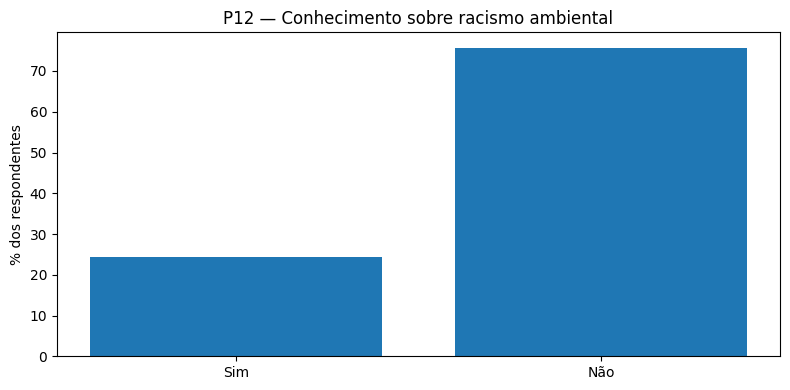

In [9]:

p12 = freq_percent("P12")
display(p12)

p26 = freq_percent("P26_1").sort_values("percentual", ascending=False)
display(p26)

plt.figure(figsize=(8, 4))
plt.bar(p12["resposta"], p12["percentual"])
plt.title("P12 — Conhecimento sobre racismo ambiental")
plt.ylabel("% dos respondentes")
plt.xlabel("")
plt.tight_layout()
plt.show()


O termo "racismo ambiental" ainda é pouco reconhecido: a maioria diz não conhecer a expressão. Em paralelo, a demanda por ação do poder público contra desigualdades aparece de forma ampla. A leitura possível é que a percepção geral de desigualdade já está consolidada, mas o vocabulário mais específico, como "racismo ambiental", circula menos entre os entrevistados.

## Discussão dos resultados

Três achados se destacam. Primeiro, o racismo é reconhecido como problema estrutural por boa parte dos entrevistados: raça/cor/etnia foi o fator mais citado para explicar as desigualdades (44,1%, à frente de classe social, com 29,0%), e a concordância com afirmações sobre tratamento policial desigual passa de 80%.

Segundo, a experiência direta de racismo é socialmente desigual. Enquanto 23,3% do total relatam já ter sofrido racismo, esse percentual sobe para 50,0% entre pretos e 24,8% entre pardos, contra 16,3% entre brancos. O qui-quadrado e o V de Cramér (0,240) mostram que essa diferença não é ruído amostral; é a relação mais clara desta parte.

Terceiro, o apoio a cotas raciais (76,2% entre respostas válidas) se divide muito mais por política do que por raça/cor: vai de 66,1% à direita a 89,0% à esquerda, mas é semelhante entre brancos, pardos e pretos. Mesmo com diagnóstico compartilhado sobre o racismo, a opinião sobre a política pública segue a clivagem ideológica.

## Conclusão

A pesquisa mostra uma opinião pública que reconhece amplamente o racismo como problema do país, mas em que a vivência pessoal é desigual entre grupos raciais, mais frequente entre pretos e pardos. As cotas têm apoio majoritário, ainda que dividido por posicionamento político. Como próximos passos, valeria aplicar pesos amostrais (caso a base os disponibilize), estimar intervalos de confiança para os subgrupos menores e comparar estes resultados com pesquisas anteriores sobre racismo e ações afirmativas, para enxergar a tendência no tempo.